# Motion analysis

Interactive notebook for exploring PCA/TSNE/UMAP motion filters and checkpoints in this repo.

# Imports

In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import spearmanr
from tqdm.auto import tqdm

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import clear_output
import time

# In a Jupyter notebook __file__ is not defined, so infer the project
# root from the current working directory (this notebook lives in
# PROJECT_ROOT / "action_query").
PROJECT_ROOT = Path.cwd().parents[0]
ACTION_QUERY_DIR = PROJECT_ROOT / "action_query"
CHECKPOINTS_DIR = ACTION_QUERY_DIR / "checkpoints"

print("Project root:", PROJECT_ROOT)
print("Action-query directory:", ACTION_QUERY_DIR)
print("Checkpoints directory:", CHECKPOINTS_DIR)

from pca_motion import (
    MOTION_ROOT,
    N_POINTS,
    N_FEAT,
    find_all_motion_files,
    get_valid_file_shapes,
    load_chunk,
    motion_to_flat,
)

Project root: /home/ashish/ARRWM
Action-query directory: /home/ashish/ARRWM/action_query
Checkpoints directory: /home/ashish/ARRWM/action_query/checkpoints


# Statistics Functions

In [3]:
def smoothness(motion):
    """Smoothness on 10x10 motion grid (single or batch).

    motion:
      - (200,) or (100, 2)         -> one sample
      - (N, 200) or (N, 100, 2)    -> batch of N samples

    Returns:
      - scalar for single sample
      - shape (N,) for batch
    """
    motion = np.asarray(motion, dtype=np.float64)

    # motion = motion / np.mean(motion, axis=-1).reshape(-1,1)
    motion = motion / (np.std(motion, axis=-1).reshape(-1, 1) + 1e-8)

    # Normalise to (..., 10, 10, 2)
    if motion.ndim == 1:
        if motion.size != 200:
            raise ValueError(f"Expected 200 elements, got {motion.size}")
        V = motion.reshape(10, 10, 2)
    elif motion.ndim == 2:
        if motion.shape == (100, 2):
            V = motion.reshape(10, 10, 2)
        elif motion.shape[1] == 200:
            V = motion.reshape(motion.shape[0], 10, 10, 2)
        else:
            raise ValueError(f"Unsupported shape {motion.shape} for 2D input")
    elif motion.ndim == 3 and motion.shape[-2:] == (10, 10):
        # already (10,10,2)-like but missing last dim check; be strict:
        if motion.shape[-1] != 2:
            raise ValueError(f"Expected last dim 2, got {motion.shape[-1]}")
        V = motion
    elif motion.ndim == 4 and motion.shape[-3:] == (10, 10, 2):
        V = motion
    else:
        raise ValueError(
            f"motion must be (200,), (100,2), (N,200), (N,100,2) or already (..,10,10,2); got {motion.shape}"
        )

    # Neighbour differences along x (horizontal) and y (vertical)
    Dx = V[..., :, 1:, :] - V[..., :, :-1, :]   # (..., 10, 9, 2)
    Dy = V[..., 1:, :, :] - V[..., :-1, :, :]   # (..., 9, 10, 2)

    # Magnitudes and mean over grid
    mag_x = np.linalg.norm(Dx, axis=-1)  # (..., 10, 9)
    mag_y = np.linalg.norm(Dy, axis=-1)  # (..., 9, 10)

    # Average over grid; result is (...,)
    smooth = mag_x.mean(axis=(-2, -1)) + mag_y.mean(axis=(-2, -1))

    return smooth
    
def energy(motion):
    """Mean absolute magnitude of motion vectors (single or batch).

    motion:
      - (200,) or (100, 2)          -> one sample
      - (N, 200) or (N, 100, 2)     -> batch of N samples

    Returns:
      - scalar for single
      - shape (N,) for batch
    """
    motion = np.asarray(motion, dtype=np.float64)

    # Normalise to (..., 100, 2)
    if motion.ndim == 1:
        if motion.size != 200:
            raise ValueError(f"Expected 200 elements, got {motion.size}")
        V = motion.reshape(100, 2)
    elif motion.ndim == 2:
        if motion.shape == (100, 2):
            V = motion
        elif motion.shape[1] == 200:
            V = motion.reshape(motion.shape[0], 100, 2)
        else:
            raise ValueError(f"Unsupported 2D shape {motion.shape}")
    elif motion.ndim == 3 and motion.shape[-2:] == (100, 2):
        V = motion
    else:
        raise ValueError(
            f"motion must be (200,), (100,2), (N,200) or (N,100,2); got {motion.shape}"
        )

    mag = np.linalg.norm(V, axis=-1)        # (..., 100)
    return mag.mean(axis=-1)  

def masked_sum_dxdy(all_dx: np.ndarray, all_dy: np.ndarray, k: float = 1.0):
    """
    Compute per-sample masked sums of dx and dy.

    Keeps only vector entries whose magnitude is within ±k std of the *global*
    mean magnitude (computed across all samples and vectors), then sums dx/dy
    across vectors per sample.

    Args:
        all_dx: (N, V) array of dx values
        all_dy: (N, V) array of dy values
        k: number of standard deviations for the band (default 1.0)

    Returns:
        sum_dx: (N,) masked sum of dx per sample
        sum_dy: (N,) masked sum of dy per sample
        mask:   (N, V) boolean mask used
    """
    if all_dx.shape != all_dy.shape:
        raise ValueError(f"all_dx and all_dy must have same shape, got {all_dx.shape} vs {all_dy.shape}")
    if all_dx.ndim != 2:
        raise ValueError(f"Expected 2D arrays (N, V). Got ndim={all_dx.ndim}")

    mag = np.hypot(all_dx, all_dy)  # (N, V)
    mean_mag = mag.mean()
    std_mag = mag.std()

    lo = mean_mag - k * std_mag
    hi = mean_mag + k * std_mag
    mask = (mag > lo) & (mag < hi)  # (N, V)

    dx_masked = np.where(mask, all_dx, 0.0)
    dy_masked = np.where(mask, all_dy, 0.0)

    sum_dx = dx_masked.sum(axis=1)
    sum_dy = dy_masked.sum(axis=1)

    return sum_dx, sum_dy, mask

def _as_100x2(x: np.ndarray) -> np.ndarray:
    """Canonicalize a *single* motion field to (100,2)."""
    x = np.asarray(x)
    if x.ndim == 1:
        if x.size != 200:
            raise ValueError(f"Expected flat size 200, got {x.size}")
        return x.reshape(100, 2)
    if x.ndim == 2:
        if x.shape == (100, 2):
            return x
        if x.shape == (2, 100):
            return x.T
    raise ValueError(f"Expected (200,) or (100,2) or (2,100), got {x.shape}")

def _as_N100x2(x: np.ndarray) -> np.ndarray:
    """Canonicalize a *batch* to (N,100,2)."""
    x = np.asarray(x)
    if x.ndim == 2 and x.shape[1] == 200:
        return x.reshape(x.shape[0], 100, 2)
    if x.ndim == 3 and x.shape[1:] == (100, 2):
        return x
    if x.ndim == 3 and x.shape[1:] == (2, 100):
        return np.transpose(x, (0, 2, 1))
    raise ValueError(f"Expected (N,200) or (N,100,2) or (N,2,100), got {x.shape}")

def radial_alignment_score(x_motion,
                           radial_template,
                           mag_thresh: float = 0.0,
                           eps: float = 1e-12,
                           weight_by_magnitude: bool = False,
                           absolute: bool = False,
                           return_angle: bool = False):
    """
    Radial alignment vs a radial template.

    - Works on a single sample or a batch.
    - Score is mean cosine similarity to the radial template (1=perfect outward, -1=inward).
    - If absolute=True, inward/outward are treated the same (uses |cos|).
    """
    # Template -> (100,2) unit
    r = _as_100x2(radial_template).astype(np.float32)
    r_norm = np.linalg.norm(r, axis=-1, keepdims=True)
    r_unit = np.zeros_like(r)
    r_mask = r_norm[..., 0] > eps
    r_unit[r_mask] = r[r_mask] / r_norm[r_mask]

    x = np.asarray(x_motion)
    is_batch = (x.ndim >= 2 and x.shape[0] != 100)  # crude but works for (N,200) / (N,100,2)

    # Motion -> (N,100,2)
    if is_batch:
        v = _as_N100x2(x).astype(np.float32)
    else:
        v = _as_100x2(x).astype(np.float32)[None, ...]  # (1,100,2)

    mags = np.linalg.norm(v, axis=-1)  # (N,100)
    v_unit = np.zeros_like(v)
    m_mask = mags > eps
    v_unit[m_mask] = (v[m_mask] / mags[m_mask][..., None])

    # Cosine per arrow
    cos = np.sum(v_unit * r_unit[None, :, :], axis=-1)  # (N,100)
    cos = np.clip(cos, -1.0, 1.0)
    if absolute:
        cos = np.abs(cos)

    # Mask out low-motion arrows (and zeros)
    use = mags > max(mag_thresh, eps)  # (N,100)

    if weight_by_magnitude:
        w = mags * use
        denom = np.sum(w, axis=1) + eps
        mean_cos = np.sum(w * cos, axis=1) / denom
        if return_angle:
            ang = np.degrees(np.sum(w * np.arccos(cos), axis=1) / denom)
    else:
        count = np.sum(use, axis=1)
        mean_cos = np.sum(cos * use, axis=1) / np.maximum(count, 1)
        mean_cos = np.where(count > 0, mean_cos, np.nan)
        if return_angle:
            ang = np.degrees(np.sum(np.arccos(cos) * use, axis=1) / np.maximum(count, 1))
            ang = np.where(count > 0, ang, np.nan)

    # Return scalar for single, vector for batch
    if not is_batch:
        return (float(mean_cos[0]), float(ang[0])) if return_angle else float(mean_cos[0])
    return (mean_cos, ang) if return_angle else mean_cos

# Visualisation Functions

In [4]:
def plot_motion_grid(motion, title="Motion grid", scale=1.0, ax=None, figsize=(4, 4)):
    """Visualise a single motion vector as a 10x10 quiver grid.

    Parameters
    ----------
    motion : np.ndarray
        Shape (200,) flat, (100, 2), or (2, 10, 10) [channel, h, w].
    title : str
        Plot title.
    scale : float
        Scaling factor for arrow lengths (passed to quiver).
    ax : matplotlib.axes.Axes, optional
        If provided, draw into this axes instead of creating a new figure.
    figsize : tuple
        Figure size when creating a new figure (ignored if ax is given).
    """
    motion = np.asarray(motion, dtype=np.float32)
    if motion.shape == (2, 10, 10):
        motion = motion.reshape(2, -1).T          # (100, 2)
    elif motion.ndim == 1:
        if motion.size != 200:
            raise ValueError(f"Expected flat size 200, got {motion.size}")
        motion = motion.reshape(100, 2)
    elif motion.shape != (100, 2):
        raise ValueError(f"Expected shape (100, 2), (200,), or (2,10,10), got {motion.shape}")

    g = 10
    dx = motion[:, 0].reshape(g, g)
    dy = motion[:, 1].reshape(g, g)
    Xg, Yg = np.meshgrid(np.arange(g), np.arange(g))

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    ax.quiver(Xg, Yg, dx, dy, angles="xy", scale_units="xy", scale=scale)
    ax.set_xlim(-0.5, g - 0.5)
    ax.set_ylim(g - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax

import time
from IPython.display import clear_output

def slideshow_from_inds(X_flat, inds, variance=None,
                        sleep_s=0.2, max_show=200, shuffle=True,
                        smoothness_fn=None, energy_fn=None, smooth_max=None,
                        extra_title_fn=None):
    """
    Slideshow through samples given by `inds`.
    - extra_title_fn(ind) can return extra string info to append (e.g., sum_dx/sum_dy)
    """
    inds = np.asarray(inds)
    print(f"Found {len(inds)} samples in selection.")
    if len(inds) == 0:
        raise ValueError("No samples in that selection.")

    if shuffle:
        inds = np.random.permutation(inds)
    inds = inds[:min(max_show, len(inds))]

    shown = 0
    for i, ind in enumerate(inds):
        vec = X_flat[ind]

        if smoothness_fn is not None and smooth_max is not None:
            s = float(smoothness_fn(vec))
            if s > smooth_max:
                continue

        clear_output(wait=True)

        vec_plot = vec * variance if variance is not None else vec

        title = f"Example {shown} | idx={ind}"
        if smoothness_fn is not None:
            title += f" | smooth={float(smoothness_fn(vec)):.2f}"
        if energy_fn is not None:
            title += f" | energy={float(energy_fn(vec)):.4f}"
        if extra_title_fn is not None:
            title += " | " + str(extra_title_fn(ind))

        plot_motion_grid(vec_plot, title=title)
        plt.show()

        shown += 1
        time.sleep(sleep_s)

def scatter_by_value(transformed, val, *,
                     title="",
                     xlabel="First principal component",
                     ylabel="Second principal component",
                     cmap="RdBu_r",
                     diverging=True,
                     center=0.0,
                     s=5, alpha=0.7,
                     clip_pct=99.5,
                     vmin=None, vmax=None,
                     cbar_label=""):
    """
    Generic 2D scatter for PCA/TSNE/etc colored by a scalar.
    - diverging=True: TwoSlopeNorm centered at `center` with symmetric robust clipping.
    - diverging=False: linear Normalize with percentile clipping.
    """
    x = transformed[:, 0]
    y = transformed[:, 1]
    val = np.asarray(val)

    if diverging:
        if vmax is None:
            vmax = np.percentile(np.abs(val), clip_pct)
            # If you know val is bounded (e.g., cosine), you can pass vmax=1.0
        if vmin is None:
            vmin = -vmax
        norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
    else:
        if (vmin is None) or (vmax is None):
            lo, hi = np.percentile(val, [100-clip_pct, clip_pct])
            vmin = lo if vmin is None else vmin
            vmax = hi if vmax is None else vmax
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    plt.figure(figsize=(6, 5))
    sc = plt.scatter(x, y, c=val, cmap=cmap, norm=norm, s=s, alpha=alpha, linewidths=0)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.colorbar(sc, label=cbar_label)
    plt.tight_layout()
    plt.show()

# PCA Functions

In [5]:
def fit_transform(vectors, n_components):
    """Fit PCA on vectors, transform them, and return encode/decode/residual functions.

    Parameters
    ----------
    vectors : np.ndarray
        Shape (n_samples, n_features), e.g. (N, 200) for motion.
    n_components : int
        Number of PCA components to keep.

    Returns
    -------
    transformed : np.ndarray
        Shape (n_samples, n_components); the fit-transformed vectors.
    encode : callable
        encode(x, n_comp=None)  (project to PCA space; n_comp uses first n_comp components).
    decode : callable
        decode(z, n_comp=None)  (reconstruct in original space; n_comp uses first n_comp).
    residual : callable
        residual(x, n_comp=None)  (reconstruction error; e.g. n_comp=2 uses only first 2 components).
    """
    vectors = np.asarray(vectors, dtype=np.float64)
    n_samples, n_features = vectors.shape
    n_comp = min(n_components, n_features, n_samples - 1)

    # Fit: mean and covariance
    mean = vectors.mean(axis=0)
    centered = vectors - mean
    cov = (centered.T @ centered) / max(centered.shape[0] - 1, 1)
    # Eigen-decompose and take top n_comp
    w, v = np.linalg.eigh(cov)
    idx = np.argsort(w)[::-1][:n_comp]
    components = v[:, idx].T   # (n_comp, n_features)

    # Variance captured per component (eigenvalues = variance along each component)
    ev = w[idx]
    total_var = w.sum()
    ev_ratio = ev / total_var
    ev_ratio_cumsum = np.cumsum(ev_ratio)
    print("PCA variance captured (per component and cumulative):")
    for i in range(n_comp):
        print(f"  component {i+1:2d}: {ev_ratio[i]*100:6.2f}%  (cumulative: {ev_ratio_cumsum[i]*100:6.2f}%)")
    print(f"  Total captured with {n_comp} components: {ev_ratio_cumsum[-1]*100:.2f}%")

    # Transform all vectors
    transformed = (centered @ components.T)   # (n_samples, n_comp)

    def encode(x, n_comp=None):
        """Project to PCA space. If n_comp is set, use only the first n_comp components."""
        x = np.asarray(x, dtype=np.float64)
        comp = components[:n_comp] if n_comp is not None else components
        return (x - mean) @ comp.T

    def decode(z, n_comp=None):
        """Reconstruct from PCA space. If n_comp is set, z should have n_comp columns (or length)."""
        z = np.asarray(z, dtype=np.float64)
        comp = components[:n_comp] if n_comp is not None else components
        return (z @ comp) + mean

    def residual(x, n_comp=None):
        """Reconstruction error: x - decode(encode(x)). Use first n_comp components if n_comp is set."""
        x = np.asarray(x, dtype=np.float64)
        return x - decode(encode(x, n_comp=n_comp), n_comp=n_comp)

    return transformed, encode, decode, residual

# Data Imports

In [6]:
# How many motion grids to load
N_SAMPLES = 2_000_000
RNG = np.random.default_rng(0)

print("Using MOTION_ROOT:", MOTION_ROOT)

motion_files = find_all_motion_files(MOTION_ROOT)
print(f"Found {len(motion_files)} motion.npy files")

valid_files, shape = get_valid_file_shapes(motion_files)
if not valid_files or shape[0] is None:
    raise RuntimeError("No valid motion files (need shape [M, 100, 3])")

n_pts, feat = shape
if n_pts != N_POINTS or feat != N_FEAT:
    raise RuntimeError(f"Expected (N, feat)=({N_POINTS}, {N_FEAT}), got ({n_pts}, {feat})")

chunk = load_chunk(valid_files, N_SAMPLES, RNG)
if chunk is None:
    raise RuntimeError("load_chunk returned None; no data loaded")

# chunk has shape (S, 100, 3); convert to flat (S, 200) dx,dy
X_flat = motion_to_flat(chunk)
variance = np.var(np.abs(X_flat))
print(variance)
X_flat = X_flat / variance
print("Loaded flat motion array of shape:", X_flat.shape)

Using MOTION_ROOT: /home/ashish/frodobots/frodobots_motion
Found 7590 motion.npy files
15.071833717899482
Loaded flat motion array of shape: (1999928, 200)


In [7]:
print(f"X_flat size: {X_flat.nbytes / 1024**2:.2f} MB")

X_flat size: 3051.65 MB


In [8]:
transformed, encode, decode, residual = fit_transform(X_flat, n_components=16)

# Extract PCA params from the encode closure as float32 torch tensors so they
# can be used inside ss_vae_loss for a fully differentiable PCA reconstruction term.
_pca_fvars  = dict(zip(encode.__code__.co_freevars,
                        [c.cell_contents for c in encode.__closure__]))
pca_mean_t  = torch.from_numpy(_pca_fvars['mean'].astype(np.float32))      # (200,)
pca_comp_t  = torch.from_numpy(_pca_fvars['components'].astype(np.float32)) # (16, 200)

PCA variance captured (per component and cumulative):
  component  1:  58.28%  (cumulative:  58.28%)
  component  2:  20.38%  (cumulative:  78.66%)
  component  3:   3.41%  (cumulative:  82.07%)
  component  4:   2.85%  (cumulative:  84.92%)
  component  5:   2.15%  (cumulative:  87.07%)
  component  6:   1.29%  (cumulative:  88.36%)
  component  7:   1.07%  (cumulative:  89.43%)
  component  8:   0.76%  (cumulative:  90.20%)
  component  9:   0.68%  (cumulative:  90.87%)
  component 10:   0.63%  (cumulative:  91.50%)
  component 11:   0.52%  (cumulative:  92.02%)
  component 12:   0.44%  (cumulative:  92.46%)
  component 13:   0.37%  (cumulative:  92.83%)
  component 14:   0.36%  (cumulative:  93.19%)
  component 15:   0.35%  (cumulative:  93.54%)
  component 16:   0.31%  (cumulative:  93.85%)
  Total captured with 16 components: 93.85%


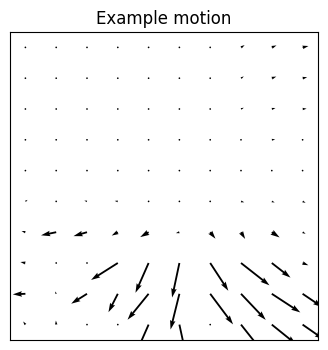

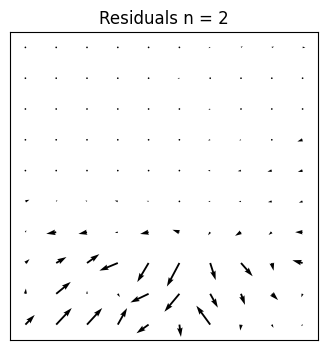

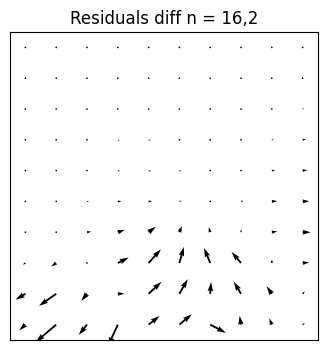

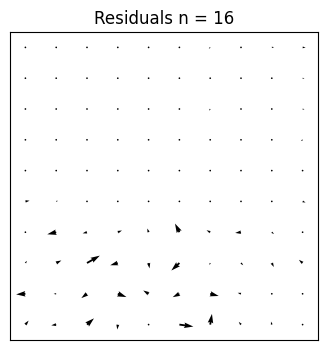

In [9]:
# Reconstruction error for first 100 samples
ind = 8
_ = plot_motion_grid(X_flat[ind], title="Example motion")
err = residual(X_flat[ind:ind+1], n_comp=2)
_ = plot_motion_grid(err[0], title="Residuals n = 2")
err_2 = residual(X_flat[ind:ind+1], n_comp=16)
_ = plot_motion_grid(err_2[0]-err[0], title="Residuals diff n = 16,2")
_ = plot_motion_grid(err_2[0], title="Residuals n = 16")


## Rotational Gradient

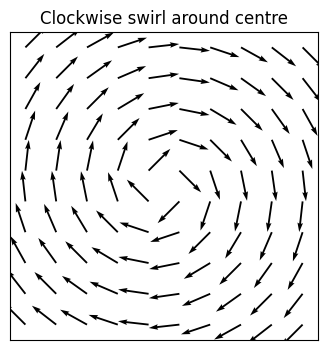

In [10]:
import numpy as np
import matplotlib.pyplot as plt

g = 10
swirl_grid = np.zeros((g, g, 2), dtype=float)

center = np.array([(g - 1) / 2, (g - 1) / 2], dtype=float)  # (4.5, 4.5)

for i in range(g):
    for j in range(g):
        p = np.array([i, j], dtype=float)   # (y, x) = (row, col)
        v = p - center                      # radial in (y, x)
        r = np.linalg.norm(v)
        if r == 0:
            swirl_grid[i, j] = 0.0
        else:
            # Clockwise tangent in (y, x): (vy, vx) -> (vx, -vy)
            t_yx = np.array([v[1], -v[0]]) / r  # still unit length

            # Convert (dy, dx) = (t_yx[0], t_yx[1]) to (dx, dy) for plotting
            swirl_grid[i, j] = np.array([t_yx[1], t_yx[0]])

swirl_flat = swirl_grid.reshape(100, 2)

plot_motion_grid(swirl_flat, title="Clockwise swirl around centre")
plt.show()

In [11]:
rot_scores = radial_alignment_score(X_flat, swirl_flat, mag_thresh=0.0)

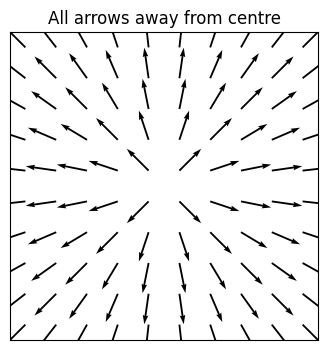

In [12]:
g = 10
radial_grid = np.zeros((g, g, 2), dtype=float)

# Centre of the 10x10 grid in index coordinates
center = np.array([(g - 1) / 2, (g - 1) / 2], dtype=float)  # (4.5, 4.5)

for i in range(g):
    for j in range(g):
        p = np.array([i, j], dtype=float)
        v = p - center              # direction: away from centre
        r = np.linalg.norm(v)
        if r == 0:
            radial_grid[i, j] = 0.0   # or pick any direction, e.g. [1, 0]
        else:
            radial_grid[i, j] = (v / r)[::-1]   # swap (dy, dx) -> (dx, dy)

# Flatten to (100, 2) for plotting
radial_flat = radial_grid.reshape(100, 2)

plot_motion_grid(radial_flat, title="All arrows away from centre")
plt.show()

In [13]:
radial_scores = radial_alignment_score(X_flat, radial_flat, mag_thresh=0.0)

In [14]:
all_dx = X_flat[:, 0::2]
all_dy = X_flat[:, 1::2]
sum_dx, sum_dy, mask = masked_sum_dxdy(all_dx, all_dy, k=1.0)

In [15]:
#Return a smoothness value for each sample in X_flat
smooth_values = smoothness(X_flat)

rand_ind = np.random.randint(0, X_flat.shape[0])
assert smoothness(X_flat[rand_ind]) == smooth_values[rand_ind]

In [16]:
#Return a smoothness value for each sample in X_flat
energy_values = energy(X_flat)

rand_ind = np.random.randint(0, X_flat.shape[0])
assert energy(X_flat[rand_ind]) == energy_values[rand_ind]

## Semi Supervised Clustering

In [17]:
try:
    from tqdm.auto import tqdm
    _has_tqdm = True
except ImportError:
    _has_tqdm = False

# ── Fully-convolutional encoder ───────────────────────────────────────────────

class FullyConvEncoder(nn.Module):
    def __init__(self, in_ch: int = 2, latent_ch: int = 16):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(in_ch, 16, 3, stride=1, padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.Conv2d(16,   32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32,   32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.conv_mu     = nn.Conv2d(32, latent_ch, 3, stride=1, padding=0)
        self.conv_logvar = nn.Conv2d(32, latent_ch, 3, stride=1, padding=0)

    def forward(self, x):
        h = self.backbone(x)
        return self.conv_mu(h), self.conv_logvar(h)


# ── Split decoder ─────────────────────────────────────────────────────────────

class SplitDecoder(nn.Module):
    def __init__(self, n_sup=4, n_free=12, out_ch=2):
        super().__init__()
        self.sup_head = nn.Sequential(
            nn.ConvTranspose2d(n_sup, 16, 3, stride=1, padding=0),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 16, 3, stride=2, padding=1, output_padding=0),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(inplace=True),
        )
        self.free_head = nn.Sequential(
            nn.ConvTranspose2d(n_free, 16, 3, stride=1, padding=0),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 16, 3, stride=2, padding=1, output_padding=0),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(inplace=True),
        )
        self.out = nn.Conv2d(16, out_ch, 3, stride=1, padding=1)

    def forward(self, z, n_sup=None):
        n_sup = n_sup if n_sup is not None else self.sup_head[0].in_channels
        z_sup  = z[:, :n_sup]
        z_free = z[:, n_sup:]
        return self.out(torch.cat([self.sup_head(z_sup), self.free_head(z_free)], dim=1))


# ── Semi-supervised beta-VAE ──────────────────────────────────────────────────

class SemiSupervisedBetaVAE(nn.Module):
    def __init__(self, in_ch: int = 2, latent_ch: int = 16,
                 n_sup: int = 5, n_free: int = 11):
        super().__init__()
        self.encoder = FullyConvEncoder(in_ch, latent_ch)
        self.decoder = SplitDecoder(n_sup=n_sup, n_free=n_free, out_ch=in_ch)
        self.latent_ch = latent_ch
        self.n_sup = n_sup

    def reparameterise(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)

    def forward(self, x, sample: bool = True):
        mu, logvar = self.encoder(x)
        z = self.reparameterise(mu, logvar) if sample else mu
        x_hat = self.decoder(z)
        return x_hat, mu, logvar, z

# ── Covariance penalty ────────────────────────────────────────────────────────

def _cov_penalty(z_free_sq, energy_scores, energy_threshold=0.3):
    mask = energy_scores > energy_threshold
    z = z_free_sq[mask]
    if z.shape[0] < 2:
        return z_free_sq.new_tensor(0.0)
    z = z - z.mean(0)
    C = (z.T @ z) / (z.shape[0] - 1)
    D = C.shape[0]
    off_diag = C - torch.diag(C.diagonal())

    # Normalise to correlation matrix so penalty is scale-invariant
    std = C.diagonal().sqrt().clamp(min=1e-8)
    corr_off = off_diag / (std[:, None] * std[None, :])

    mean_penalty = (corr_off ** 2).sum() / (D * (D - 1))
    max_penalty  = corr_off.abs().max() ** 2  # hardest outlier pair

    return mean_penalty + max_penalty

# ── Shape sanity check ────────────────────────────────────────────────────────

_dummy = torch.zeros(4, 2, 10, 10)
_enc   = FullyConvEncoder()
_dec   = SplitDecoder(n_sup=5, n_free=11)
_mu, _lv = _enc(_dummy)
_out = _dec(_mu)
assert _mu.shape  == (4, 16, 1, 1), f"encoder output shape mismatch: {_mu.shape}"
assert _out.shape == (4, 2, 10, 10), f"decoder output shape mismatch: {_out.shape}"
print("Architecture shapes OK:")
print(f"  encoder mu/logvar : {tuple(_mu.shape)}  (= [B, 1, 1, 16] channels-last)")
print(f"  decoder output    : {tuple(_out.shape)} (= [B, 10, 10, 2] channels-last)")
del _dummy, _enc, _dec, _mu, _lv, _out

# ── Live-plot helper ─────────────────────────────────────────────────────────

def _draw_curves(hist, epoch, n_epochs, beta_sup, beta_free, cov_weight, aux_weight):
    plt.close("all")
    fig, axes = plt.subplots(1, 6, figsize=(30, 4))
    ex = range(1, len(hist["train"]) + 1)

    axes[0].plot(ex, hist["train"], label="train")
    axes[0].plot(ex, hist["val"],   label="val")
    axes[0].set_title("Total loss"); axes[0].legend(); axes[0].set_xlabel("epoch")

    axes[1].plot(ex, hist["pca"], label="pca_recon", color="tab:green")
    axes[1].set_title("PCA recon loss"); axes[1].legend(); axes[1].set_xlabel("epoch")

    axes[2].plot(ex, hist["kl_sup"],  label=f"KL_sup (b={beta_sup})")
    axes[2].plot(ex, hist["kl_free"], label=f"KL_free (b={beta_free})")
    axes[2].set_title("KL divergence"); axes[2].legend(); axes[2].set_xlabel("epoch")

    axes[3].plot(ex, hist["cov"], label="cov penalty", color="purple")
    axes[3].set_title("Off-diagonal covariance\n(free dims, high-energy only)")
    axes[3].legend(); axes[3].set_xlabel("epoch")

    axes[4].plot(ex, hist["aux"],     label="aux (raw MAE)")
    axes[4].plot(ex, hist["aux_raw"], label=f"aux x{aux_weight} (weighted)", linestyle="--")
    axes[4].set_title("Auxiliary loss\n(sup mu <-> scores)")
    axes[4].legend(); axes[4].set_xlabel("epoch")

    _erange = range(1, n_epochs + 1)
    _asc = [beta_sup  * kl_annealing_factor(e, n_epochs) for e in _erange]
    _afc = [beta_free * kl_annealing_factor(e, n_epochs) for e in _erange]
    axes[5].plot(_asc, label=f"b_sup  (->{beta_sup})")
    axes[5].plot(_afc, label=f"b_free (->{beta_free})")
    axes[5].axhline(cov_weight, color="purple", linestyle="--",
                    label=f"cov_weight={cov_weight}")
    axes[5].axvline(epoch, color="gray", linestyle=":", alpha=0.6, label=f"epoch {epoch}")
    axes[5].set_title("Annealing schedules")
    axes[5].set_xlabel("epoch"); axes[5].set_ylabel("effective weight"); axes[5].legend()

    fig.suptitle(
        f"Epoch {epoch}/{n_epochs}  --  "
        f"train={hist['train'][-1]:.4f}  val={hist['val'][-1]:.4f}  "
        f"recon={hist['recon'][-1]:.4f}  pca={hist['pca'][-1]:.4f}  "
        f"cov={hist['cov'][-1]:.4f}  aux={hist['aux'][-1]:.4f}",
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()


Architecture shapes OK:
  encoder mu/logvar : (4, 16, 1, 1)  (= [B, 1, 1, 16] channels-last)
  decoder output    : (4, 2, 10, 10) (= [B, 10, 10, 2] channels-last)


In [18]:
# ── Magnitude compression + inversion ─────────────────────────────────────────

def mag_compress(v, scale):
    """Compress: new_mag = mag * (1-s) + s.  v: [N, 2, 10, 10] tensor or numpy."""
    if isinstance(v, torch.Tensor):
        mag  = torch.linalg.norm(v, dim=1, keepdim=True)   # [N, 1, 10, 10]
        unit = v / (mag + 1e-8)
        compressed_mag = mag * (1.0 - scale) + scale
        return compressed_mag * unit
    else:
        mag  = np.linalg.norm(v, axis=1, keepdims=True)
        unit = v / (mag + 1e-8)
        compressed_mag = mag * (1.0 - scale) + scale
        return (compressed_mag * unit).astype(np.float32)

def mag_compress_np(v, scale):
    return mag_compress(v, scale)

def mag_decompress_np(v, scale):
    """Invert: original_mag = (compressed_mag - s) / (1-s).  v: [N, 2, 10, 10] numpy."""
    if scale == 0.0:
        return v
    mag  = np.linalg.norm(v, axis=1, keepdims=True)
    unit = v / (mag + 1e-8)
    original_mag = np.clip((mag - scale) / (1.0 - scale), 0.0, None)
    return (original_mag * unit).astype(np.float32)


def ss_vae_loss(x, x_hat, mu, logvar, z, score_targets,
                n_sup: int = 5,
                beta_sup: float = 1.0, beta_free: float = 1.0,
                cov_weight: float = 0.0,
                aux_weight: float = 3.0, free_bits: float = 0.2,
                energy_threshold: float = 0.3,
                recon_weight: float = 1.0,
                pca_weight: float = 0.0):
    recon = F.l1_loss(mag_compress(x_hat, MAG_SCALE), mag_compress(x, MAG_SCALE), reduction='mean')

    # Differentiable PCA reconstruction loss: project both input and reconstruction
    # into PCA space and penalise the distance there.  pca_mean_t / pca_comp_t are
    # float32 torch tensors built from the encode() closure after fit_transform().
    _mn       = pca_mean_t.to(x.device)                                           # (D,)
    _cp       = pca_comp_t[PCA_SKIP:PCA_SKIP + PCA_COMPONENTS].to(x.device)       # (K, D)
    _flat     = lambda v: (v.permute(0, 2, 3, 1).reshape(v.shape[0], -1).float() * _scale)
    pca_x     = (_flat(x)     - _mn) @ _cp.T                 # (N, K)
    pca_x_hat = (_flat(x_hat) - _mn) @ _cp.T                 # (N, K)
    pca_recon = F.l1_loss(pca_x_hat, pca_x, reduction='mean')

    kl_elem = -0.5 * (1.0 + logvar - mu.pow(2) - logvar.exp())

    kl_free_per_dim = kl_elem[:, n_sup:].mean(dim=0)
    kl_free = torch.clamp(kl_free_per_dim, min=free_bits).mean()
    kl_sup  = kl_elem[:, :n_sup].mean()

    _sq = lambda t: t.squeeze(-1).squeeze(-1)

    energy_col = torch.linalg.norm(x, dim=1).mean(dim=(-2, -1))  # per-sample mean magnitude
    cov = _cov_penalty(_sq(z[:, n_sup:]), energy_col, energy_threshold)

    mu_flat = _sq(mu)
    _aw = AUX_WEIGHTS.to(x.device)                                         # (n_sup,)
    aux = (mu_flat[:, :n_sup] - score_targets).abs().mul(_aw).mean()

    total = (recon_weight * recon + beta_sup * kl_sup + beta_free * kl_free
             + cov_weight * cov + aux_weight * aux
             + pca_weight * pca_recon)
    return (total,
            recon.item(), kl_sup.item(), kl_free.item(), cov.item(),
            aux.item(), (aux_weight * aux).item(),
            pca_recon.item(), 0.0)


# ── Hyper-parameters ─────────────────────────────────────────────────────────

DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"
N_SUPERVISED    = 3
N_FREE          = 14
LATENT_CH       = N_SUPERVISED + N_FREE
BETA_SUP        = 0.5 #was 1.0
BETA_FREE       = 0.5 #was 1.0
COV_WEIGHT      = 20.0 #was 12.0
ENERGY_COV_THR  = 0.0
FREE_BITS       = 0.2
AUX_WEIGHT      = 2.0
AUX_WEIGHTS     = torch.tensor([1., 1., 1.])  # per-axis: [radial, dx, dy]
MAG_SCALE       = 0.75     # 0.0 = unchanged, 1.0 = fully unit-normed
RECON_WEIGHT    = 1.0      # set >0 to re-enable pixel-space L1 recon loss
PCA_SKIP        = 0        # skip the top-N PCA components (already covered by recon)
PCA_COMPONENTS  = 16        # number of mid-range PCA components to penalise
PCA_WEIGHT      = 10.0     # needs to compete with KL + cov + aux
BATCH_SIZE      = 512
N_EPOCHS        = 100
LR              = 3e-4
LIVE_PLOT_EVERY = 2


# ── Data preparation ──────────────────────────────────────────────────────────

_X = X_flat.reshape(-1, 10, 10, 2).transpose(0, 3, 1, 2).astype(np.float32)
_scale = float(np.percentile(np.abs(_X), 99)) + 1e-8
X_grid_norm = (_X / _scale).astype(np.float32)

# Apply magnitude compression to training data
# X_grid_norm = mag_compress_np(X_grid_raw, MAG_SCALE)

X_grid_raw = _X

print(f"MAG_SCALE     : {MAG_SCALE}")
_raw_mag = np.linalg.norm(X_grid_raw, axis=1)
_comp_mag = np.linalg.norm(X_grid_norm, axis=1)
print(f"  raw mag range       : [{_raw_mag.min():.4f}, {_raw_mag.max():.4f}]")
print(f"  compressed mag range: [{_comp_mag.min():.4f}, {_comp_mag.max():.4f}]")

# Verify round-trip
_roundtrip = mag_decompress_np(X_grid_norm, MAG_SCALE)
_rt_err = np.abs(_roundtrip - X_grid_raw).max()
print(f"  round-trip max error: {_rt_err:.8f}")

def _norm_minmax(s):
    s = np.asarray(s, dtype=np.float32)
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo + 1e-8)

def _norm_zscore(s):
    s = np.asarray(s, dtype=np.float32)
    return (s - s.mean()) / (s.std() + 1e-8)

scores_norm = np.stack([
    _norm_minmax(radial_scores),
    _norm_zscore(sum_dx),
    _norm_zscore(sum_dy),
], axis=1).astype(np.float32)

N_total = len(X_grid_norm)
_rng    = np.random.default_rng(42)
_perm   = _rng.permutation(N_total)
_val_n  = max(512, int(0.05 * N_total))
_val_idx, _train_idx = _perm[:_val_n], _perm[_val_n:]

_Xt = torch.from_numpy(X_grid_norm[_train_idx])
_st = torch.from_numpy(scores_norm[_train_idx])
_Xv = torch.from_numpy(X_grid_norm[_val_idx])
_sv = torch.from_numpy(scores_norm[_val_idx])

_nw = min(2, os.cpu_count() or 1)
train_loader_ss = DataLoader(TensorDataset(_Xt, _st), batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=_nw, pin_memory=True)
val_loader_ss   = DataLoader(TensorDataset(_Xv, _sv), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=_nw, pin_memory=True)

print(f"Device        : {DEVICE}")
print(f"Train samples : {len(_train_idx):,}   |   Val samples: {_val_n:,}")
# print(f"Input scale   : {_scale:.4f}")


# ── Model ────────────────────────────────────────────────────────────────────

ss_vae = SemiSupervisedBetaVAE(in_ch=2, latent_ch=LATENT_CH,
                                n_sup=N_SUPERVISED, n_free=N_FREE).to(DEVICE)
print(f"Parameters    : {sum(p.numel() for p in ss_vae.parameters()):,}")

_opt  = optim.Adam(ss_vae.parameters(), lr=LR)
_sched = optim.lr_scheduler.CosineAnnealingLR(_opt, T_max=N_EPOCHS)

_hist = {"train": [], "val": [], "recon": [], "pca": [], "kl_sup": [], "kl_free": [],
         "cov": [], "aux": [], "aux_raw": []}





MAG_SCALE     : 0.75
  raw mag range       : [0.0000, 7.6022]
  compressed mag range: [0.0000, 5.9974]
  round-trip max error: 12.73283958
Device        : cuda
Train samples : 1,899,932   |   Val samples: 99,996
Parameters    : 33,908


In [ ]:
# torch.save({
#     'model_state': ss_vae.state_dict(),
#     'hparams': {
#         'N_SUPERVISED': N_SUPERVISED,
#         'N_FREE': N_FREE,
#         'LATENT_CH': LATENT_CH,
#         'BETA_SUP': BETA_SUP,
#         'BETA_FREE': BETA_FREE,
#         'COV_WEIGHT': COV_WEIGHT,
#         'PCA_WEIGHT': PCA_WEIGHT,
#         'PCA_COMPONENTS': PCA_COMPONENTS,
#         'PCA_SKIP': PCA_SKIP,
#         'AUX_WEIGHT': AUX_WEIGHT,
#         'MAG_SCALE': MAG_SCALE,
#         'FREE_BITS': FREE_BITS,
#     },
#     'pca_mean': pca_mean_t,
#     'pca_comp': pca_comp_t,
#     'scale': _scale,
# }, CHECKPOINTS_DIR / "ss_vae_3sup_14free.pt")

In [19]:
ckpt = torch.load(CHECKPOINTS_DIR / "ss_vae_3sup_14free.pt", map_location="cpu")

hp = ckpt['hparams']
ss_vae = SemiSupervisedBetaVAE(
    in_ch=2,
    latent_ch=hp['LATENT_CH'],
    n_sup=hp['N_SUPERVISED'],
    n_free=hp['N_FREE'],
).to(DEVICE)
ss_vae.load_state_dict(ckpt['model_state'])
ss_vae.eval()

# Restore PCA tensors and scale
pca_mean_t = ckpt['pca_mean']
pca_comp_t = ckpt['pca_comp']
_scale     = ckpt['scale']

# Restore hyperparams as globals if needed
N_SUPERVISED = hp['N_SUPERVISED']
N_FREE       = hp['N_FREE']
LATENT_CH    = hp['LATENT_CH']

print(f"Loaded: {hp['N_SUPERVISED']} sup + {hp['N_FREE']} free = {hp['LATENT_CH']} latent dims")

Loaded: 3 sup + 14 free = 17 latent dims


In [21]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import torch
import matplotlib.pyplot as plt

ss_vae.eval()

# Slider ranges: use the actual latent distribution to set sensible bounds
_subsample = np.random.choice(len(X_grid_norm), size=10_000, replace=False)
with torch.no_grad():
    _all_z = []
    for (xb,) in DataLoader(TensorDataset(torch.from_numpy(X_grid_norm[_subsample])),
                              batch_size=1024, shuffle=False):
        _, mu, _, _ = ss_vae(xb.to(DEVICE), sample=False)
        _all_z.append(mu.squeeze(-1).squeeze(-1).cpu().numpy())
    Z_stats = np.concatenate(_all_z, axis=0)
    Z_mean = Z_stats.mean(axis=0)
    Z_std  = Z_stats.std(axis=0)

N_RANGE = 3.0  # slider covers ±3 std

dim_names = (
    [f"z{i} (sup)" for i in range(N_SUPERVISED)] +
    [f"z{i} (free)" for i in range(N_SUPERVISED, LATENT_CH)]
)

sliders = []
for i in range(LATENT_CH):
    lo = float(Z_mean[i] - N_RANGE * Z_std[i])
    hi = float(Z_mean[i] + N_RANGE * Z_std[i])
    s = widgets.FloatSlider(
        value=float(Z_mean[i]),
        min=lo, max=hi,
        step=(hi - lo) / 200,
        description=dim_names[i],
        style={'description_width': '100px'},
        layout=widgets.Layout(width='500px'),
        continuous_update=False,
    )
    sliders.append(s)

reset_btn = widgets.Button(description="Reset to mean", layout=widgets.Layout(width='150px'))
output = widgets.Output()

def decode_and_plot(**kwargs):
    z = np.array([kwargs[dim_names[i]] for i in range(LATENT_CH)], dtype=np.float32)
    z_t = torch.from_numpy(z).reshape(1, LATENT_CH, 1, 1).to(DEVICE)

    with torch.no_grad():
        x_hat = ss_vae.decoder(z_t)
    motion = x_hat[0].cpu().numpy()  # (2, 10, 10)

    with output:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(5, 5))
        plot_motion_grid(motion, title="Decoded motion", ax=ax)
        plt.tight_layout()
        plt.show()

def on_reset(btn):
    for i, s in enumerate(sliders):
        s.value = float(Z_mean[i])

reset_btn.on_click(on_reset)

interactive_out = widgets.interactive_output(
    decode_and_plot,
    {dim_names[i]: sliders[i] for i in range(LATENT_CH)}
)

# Layout: sliders on the left, plot on the right
slider_box = widgets.VBox([reset_btn] + sliders)
display(widgets.HBox([slider_box, output]))
display(interactive_out)

Output()

radial=0.680  sum_dx=2.232  sum_dy=-0.524
free dims: [ 1.7826583  -1.7827483   0.3484366  -0.86328197  0.12719838 -0.46308294
  2.3746045   0.62907237  1.5375564  -0.83511573  2.5753205  -0.5014659
 -0.5559434   1.876875  ]


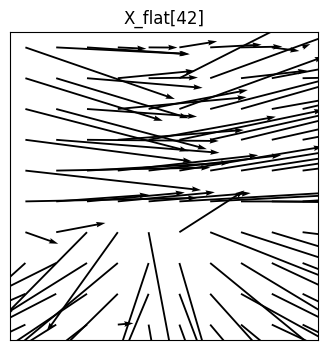

(100, 17)


In [32]:
ind = 6

# Single sample
z = encode_motion(X_flat[ind ])
print(f"radial={z[0]:.3f}  sum_dx={z[1]:.3f}  sum_dy={z[2]:.3f}")
print(f"free dims: {z[3:]}")

plot_motion_grid(X_flat[ind] * variance, title=f"X_flat[42]")
plt.show()

# Batch
z_batch = encode_motion(X_flat[:100])
print(z_batch.shape)  # (100, 17)

In [21]:
def encode_motion(motion, ss_vae=ss_vae, scale=_scale, device=DEVICE):
    """
    Encode a motion grid into VAE latent space.
    
    Parameters
    ----------
    motion : np.ndarray
        Shape (200,), (100, 2), (2, 10, 10), or batched (N, 200) / (N, 100, 2) / (N, 2, 10, 10)
    
    Returns
    -------
    z : np.ndarray
        Shape (LATENT_CH,) for single sample, (N, LATENT_CH) for batch.
    """
    motion = np.asarray(motion, dtype=np.float32)
    single = False

    # Normalise to (N, 2, 10, 10)
    if motion.shape == (200,):
        motion = motion.reshape(1, 10, 10, 2).transpose(0, 3, 1, 2)
        single = True
    elif motion.shape == (100, 2):
        motion = motion.reshape(1, 10, 10, 2).transpose(0, 3, 1, 2)
        single = True
    elif motion.shape == (2, 10, 10):
        motion = motion[None]
        single = True
    elif motion.ndim == 2 and motion.shape[1] == 200:
        motion = motion.reshape(-1, 10, 10, 2).transpose(0, 3, 1, 2)
    elif motion.ndim == 3 and motion.shape[1:] == (100, 2):
        motion = motion.reshape(-1, 10, 10, 2).transpose(0, 3, 1, 2)
    elif motion.ndim == 4 and motion.shape[1:] == (2, 10, 10):
        pass
    else:
        raise ValueError(f"Unsupported motion shape: {motion.shape}")

    x = torch.from_numpy(motion / scale).to(device)

    ss_vae.eval()
    with torch.no_grad():
        _, mu, _, _ = ss_vae(x, sample=False)
    z = mu.squeeze(-1).squeeze(-1).cpu().numpy()

    return z[0] if single else z

In [22]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.graph_objects as go
import plotly.express as px

# ── Encode a subsample into VAE latent space ──────────────────────────────────
N_VIS = 50_000
_vis_rng = np.random.default_rng(0)
_vis_idx = _vis_rng.choice(len(X_flat), size=N_VIS, replace=False)

Z_vis = encode_motion(X_flat[_vis_idx])  # (N_VIS, 17)

# ── Cluster in full latent space ──────────────────────────────────────────────
N_CLUSTERS = 8

km = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42)
labels = km.fit_predict(Z_vis)

# ── Reduce to 3D for visualization ───────────────────────────────────────────
pca_3d = PCA(n_components=3)
Z_3d = pca_3d.fit_transform(Z_vis)

print(f"3D PCA explains {pca_3d.explained_variance_ratio_.sum()*100:.1f}% of latent variance")

# ── Interactive 3D scatter ────────────────────────────────────────────────────
fig = go.Figure()

colors = px.colors.qualitative.Set1

for c in range(N_CLUSTERS):
    mask = labels == c
    fig.add_trace(go.Scatter3d(
        x=Z_3d[mask, 0],
        y=Z_3d[mask, 1],
        z=Z_3d[mask, 2],
        mode='markers',
        marker=dict(size=1.5, color=colors[c % len(colors)], opacity=0.6),
        name=f'Cluster {c} ({mask.sum():,})',
        text=[f'idx={_vis_idx[i]}' for i in np.where(mask)[0]],
        hoverinfo='text+name',
    ))

# Add cluster centers
centers_3d = pca_3d.transform(km.cluster_centers_)
fig.add_trace(go.Scatter3d(
    x=centers_3d[:, 0],
    y=centers_3d[:, 1],
    z=centers_3d[:, 2],
    mode='markers+text',
    marker=dict(size=6, color='black', symbol='diamond'),
    text=[f'C{i}' for i in range(N_CLUSTERS)],
    textposition='top center',
    name='Centers',
    hoverinfo='text',
))

fig.update_layout(
    title=f'VAE Latent Space — {N_CLUSTERS} Clusters (PCA → 3D)',
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3',
    ),
    width=900, height=700,
    legend=dict(itemsizing='constant'),
)
fig.show()

3D PCA explains 37.6% of latent variance


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

cluster_slider = widgets.IntSlider(
    value=0, min=0, max=N_CLUSTERS - 1,
    description='Cluster:', style={'description_width': '80px'},
    layout=widgets.Layout(width='400px'),
)
n_show = widgets.IntSlider(
    value=8, min=1, max=16,
    description='Samples:', style={'description_width': '80px'},
    layout=widgets.Layout(width='400px'),
)
resample_btn = widgets.Button(description="Resample", layout=widgets.Layout(width='120px'))
output = widgets.Output()

def show_cluster(c, n):
    cluster_inds = _vis_idx[labels == c]
    samples = np.random.choice(cluster_inds, size=min(n, len(cluster_inds)), replace=False)
    n_actual = len(samples)
    cols = min(8, n_actual)
    rows = (n_actual + cols - 1) // cols

    with output:
        clear_output(wait=True)
        print(f"Cluster {c}: {(labels == c).sum():,} samples")
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
        if rows == 1 and cols == 1:
            axes = np.array([axes])
        axes = np.atleast_2d(axes)
        for i in range(n_actual):
            r, col = divmod(i, cols)
            plot_motion_grid(X_flat[samples[i]] * variance,
                           title=f"idx={samples[i]}", ax=axes[r, col])
        for i in range(n_actual, rows * cols):
            r, col = divmod(i, cols)
            axes[r, col].axis('off')
        plt.suptitle(f"Cluster {c} — random samples", fontsize=14)
        plt.tight_layout()
        plt.show()

def on_change(*args):
    show_cluster(cluster_slider.value, n_show.value)

cluster_slider.observe(on_change, names='value')
n_show.observe(on_change, names='value')
resample_btn.on_click(on_change)

display(widgets.HBox([cluster_slider, n_show, resample_btn]))
display(output)
show_cluster(0, 8)

Output()

In [26]:
# ── Per-cluster latent ranges (5th–95th percentile) ──────────────────────────
dim_names = (
    ["radial", "sum_dx", "sum_dy"] +
    [f"z{i}" for i in range(N_SUPERVISED, LATENT_CH)]
)

for c in range(N_CLUSTERS):
    z_c = Z_vis[labels == c]
    print(f"Cluster {c}  ({(labels == c).sum():,} samples)")
    for d in range(LATENT_CH):
        lo = np.percentile(z_c[:, d], 5)
        hi = np.percentile(z_c[:, d], 95)
        print(f"  {dim_names[d]:>8}: [{lo:+.3f}, {hi:+.3f}]")
    print()

Cluster 0  (3,551 samples)
    radial: [+0.465, +0.724]
    sum_dx: [-3.976, -0.953]
    sum_dy: [-1.222, +1.289]
        z3: [-1.122, +1.130]
        z4: [-1.679, +0.981]
        z5: [-1.022, +1.554]
        z6: [-1.065, +1.779]
        z7: [-1.471, +1.108]
        z8: [-1.442, +1.137]
        z9: [-1.218, +1.471]
       z10: [-0.931, +1.311]
       z11: [+0.035, +1.589]
       z12: [+0.805, +3.326]
       z13: [-1.856, +1.012]
       z14: [-1.468, +1.152]
       z15: [-1.455, +1.379]
       z16: [-1.400, +1.338]

Cluster 1  (16,229 samples)
    radial: [+0.439, +0.656]
    sum_dx: [-0.154, +0.204]
    sum_dy: [-0.562, -0.188]
        z3: [-0.234, +0.310]
        z4: [-0.377, +0.255]
        z5: [-0.190, +0.371]
        z6: [-0.202, +0.287]
        z7: [-0.324, +0.301]
        z8: [-0.266, +0.250]
        z9: [-0.326, +0.209]
       z10: [-0.252, +0.472]
       z11: [-1.099, +0.024]
       z12: [-0.285, +0.250]
       z13: [-0.191, +0.379]
       z14: [-0.212, +0.213]
       z15: [-0.

In [27]:
import ipywidgets as widgets
from IPython.display import display, clear_output

ss_vae.eval()

# ── Compute cluster centers ───────────────────────────────────────────────────
cluster_centers = np.array([Z_vis[labels == c].mean(axis=0) for c in range(N_CLUSTERS)])

# ── Slider ranges from full latent distribution ───────────────────────────────
Z_mean = Z_vis.mean(axis=0)
Z_std  = Z_vis.std(axis=0)
N_RANGE = 3.0

dim_names = (
    ["radial", "sum_dx", "sum_dy"] +
    [f"z{i}" for i in range(N_SUPERVISED, LATENT_CH)]
)

# ── Build sliders ─────────────────────────────────────────────────────────────
sliders = []
for i in range(LATENT_CH):
    lo = float(Z_mean[i] - N_RANGE * Z_std[i])
    hi = float(Z_mean[i] + N_RANGE * Z_std[i])
    s = widgets.FloatSlider(
        value=float(Z_mean[i]),
        min=lo, max=hi,
        step=(hi - lo) / 200,
        description=dim_names[i],
        style={'description_width': '100px'},
        layout=widgets.Layout(width='500px'),
        continuous_update=False,
    )
    sliders.append(s)

# ── Cluster selector ──────────────────────────────────────────────────────────
cluster_dropdown = widgets.Dropdown(
    options=[("Mean", -1)] + [(f"Cluster {c}", c) for c in range(N_CLUSTERS)],
    value=-1,
    description="Init from:",
    style={'description_width': '80px'},
    layout=widgets.Layout(width='250px'),
)

reset_btn = widgets.Button(description="Reset to mean", layout=widgets.Layout(width='140px'))
output = widgets.Output()

# ── Decode and plot ───────────────────────────────────────────────────────────
def decode_and_plot(*args):
    z = np.array([s.value for s in sliders], dtype=np.float32)
    z_t = torch.from_numpy(z).reshape(1, LATENT_CH, 1, 1).to(DEVICE)
    with torch.no_grad():
        x_hat = ss_vae.decoder(z_t)
    motion = x_hat[0].cpu().numpy()
    with output:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(5, 5))
        plot_motion_grid(motion, title="Decoded motion", ax=ax)
        plt.tight_layout()
        plt.show()

for s in sliders:
    s.observe(decode_and_plot, names='value')

# ── Set sliders from cluster ──────────────────────────────────────────────────
def on_cluster_select(change):
    c = change['new']
    vals = Z_mean if c == -1 else cluster_centers[c]
    for i, s in enumerate(sliders):
        s.value = float(np.clip(vals[i], s.min, s.max))

cluster_dropdown.observe(on_cluster_select, names='value')

def on_reset(btn):
    cluster_dropdown.value = -1
    for i, s in enumerate(sliders):
        s.value = float(Z_mean[i])

reset_btn.on_click(on_reset)

# ── Layout ────────────────────────────────────────────────────────────────────
controls = widgets.VBox([widgets.HBox([cluster_dropdown, reset_btn])] + sliders)
display(widgets.HBox([controls, output]))
decode_and_plot()

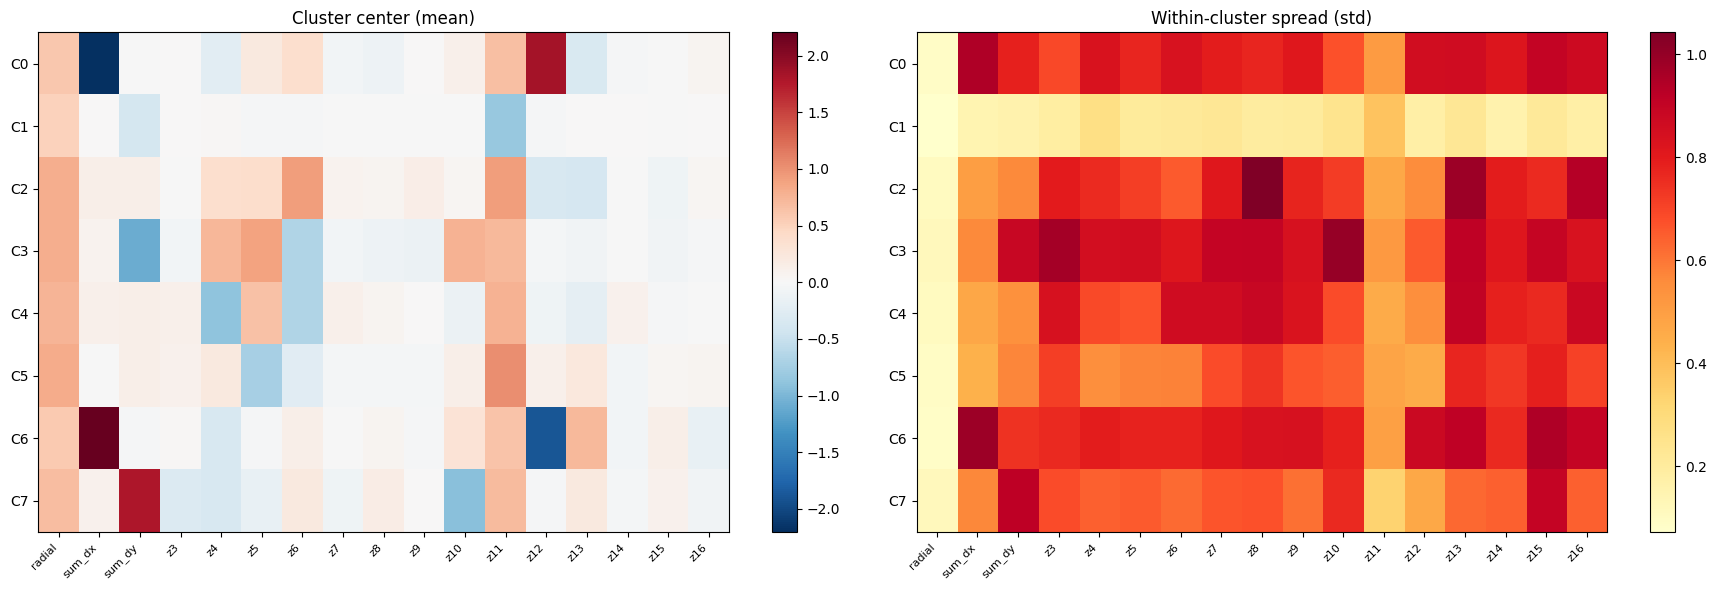

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, N_CLUSTERS * 0.5 + 2))

# Heatmap of cluster center means
centers = np.array([Z_vis[labels == c].mean(axis=0) for c in range(N_CLUSTERS)])
im0 = axes[0].imshow(centers, aspect='auto', cmap='RdBu_r',
                      vmin=-np.abs(centers).max(), vmax=np.abs(centers).max())
axes[0].set_xticks(range(LATENT_CH))
axes[0].set_xticklabels(dim_names, rotation=45, ha='right', fontsize=8)
axes[0].set_yticks(range(N_CLUSTERS))
axes[0].set_yticklabels([f"C{c}" for c in range(N_CLUSTERS)])
axes[0].set_title("Cluster center (mean)")
plt.colorbar(im0, ax=axes[0])

# Heatmap of within-cluster std
stds = np.array([Z_vis[labels == c].std(axis=0) for c in range(N_CLUSTERS)])
im1 = axes[1].imshow(stds, aspect='auto', cmap='YlOrRd')
axes[1].set_xticks(range(LATENT_CH))
axes[1].set_xticklabels(dim_names, rotation=45, ha='right', fontsize=8)
axes[1].set_yticks(range(N_CLUSTERS))
axes[1].set_yticklabels([f"C{c}" for c in range(N_CLUSTERS)])
axes[1].set_title("Within-cluster spread (std)")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

In [ ]:
# ── Training loop ─────────────────────────────────────────────────────────────

def kl_annealing_factor(epoch, n_epochs, warmup_frac=0.4):
    return min(1.0, epoch / (warmup_frac * n_epochs))

_epochs = tqdm(range(1, N_EPOCHS + 1), desc="training") if _has_tqdm else range(1, N_EPOCHS + 1)

for epoch in _epochs:
    _anneal   = kl_annealing_factor(epoch, N_EPOCHS)
    _bsup_eff = BETA_SUP  * _anneal
    _bfre_eff = BETA_FREE * _anneal

    ss_vae.train()
    _tot = _rec = _kl_sup_ = _kl_fre_ = _cov_ = _aux_ = _aux_raw_ = _pca_ = 0.0

    for xb, sb in train_loader_ss:
        xb, sb = xb.to(DEVICE), sb.to(DEVICE)
        x_hat, mu, logvar, z = ss_vae(xb)
        loss, rec, kl_sup_v, kl_fre_v, cov_v, aux_v, aux_raw_v, pca_v, _ = ss_vae_loss(
            xb, x_hat, mu, logvar, z, sb,
            n_sup=N_SUPERVISED,
            beta_sup=_bsup_eff, beta_free=_bfre_eff,
            cov_weight=COV_WEIGHT,
            aux_weight=AUX_WEIGHT, free_bits=FREE_BITS,
            energy_threshold=ENERGY_COV_THR,
            recon_weight=RECON_WEIGHT,
            pca_weight=PCA_WEIGHT)
        _opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ss_vae.parameters(), max_norm=1.0)
        _opt.step()
        _tot      += loss.item()
        _rec      += rec
        _kl_sup_  += kl_sup_v
        _kl_fre_  += kl_fre_v
        _cov_     += cov_v
        _aux_     += aux_v
        _aux_raw_ += aux_raw_v
        _pca_     += pca_v

    nb = len(train_loader_ss)
    _hist["train"].append(_tot      / nb)
    _hist["recon"].append(_rec      / nb)
    _hist["pca"].append(  _pca_     / nb)
    _hist["kl_sup"].append(_kl_sup_ / nb)
    _hist["kl_free"].append(_kl_fre_ / nb)
    _hist["cov"].append(  _cov_     / nb)
    _hist["aux"].append(  _aux_     / nb)
    _hist["aux_raw"].append(_aux_raw_ / nb)

    ss_vae.eval()
    _vtot = 0.0
    with torch.no_grad():
        for xb, sb in val_loader_ss:
            xb, sb = xb.to(DEVICE), sb.to(DEVICE)
            x_hat, mu, logvar, z = ss_vae(xb, sample=False)
            l, *_ = ss_vae_loss(xb, x_hat, mu, logvar, z, sb,
                                 n_sup=N_SUPERVISED,
                                 beta_sup=_bsup_eff, beta_free=_bfre_eff,
                                 cov_weight=COV_WEIGHT,
                                 aux_weight=AUX_WEIGHT, free_bits=FREE_BITS,
                                 energy_threshold=ENERGY_COV_THR,
                                 recon_weight=RECON_WEIGHT,
                                 pca_weight=PCA_WEIGHT)
            _vtot += l.item()
    _hist["val"].append(_vtot / len(val_loader_ss))
    _sched.step()

    if _has_tqdm:
        _epochs.set_postfix(
            recon=f"{_hist['recon'][-1]:.4f}",
            kl_f=f"{_hist['kl_free'][-1]:.4f}",
            cov=f"{_hist['cov'][-1]:.4f}",
            aux=f"{_hist['aux'][-1]:.4f}",
            val=f"{_hist['val'][-1]:.4f}",
            bf=f"{_bfre_eff:.2f}",
        )

    if epoch % LIVE_PLOT_EVERY == 0 or epoch == N_EPOCHS:
        clear_output(wait=True)
        _draw_curves(_hist, epoch, N_EPOCHS, BETA_SUP, BETA_FREE, COV_WEIGHT, AUX_WEIGHT)

        # ── Reconstruction visualisation (decompressed back to original scale) ──
        _rng_vis = np.random.default_rng(0)
        _vis_idx = _rng_vis.integers(0, N_total, size=8)
        _x_vis   = torch.from_numpy(X_grid_norm[_vis_idx]).to(DEVICE)
        with torch.no_grad():
            _x_hat_vis, _, _, _ = ss_vae(_x_vis, sample=False)
        _x_comp  = _x_vis.cpu().numpy()
        _xh_comp = _x_hat_vis.cpu().numpy()

        # Invert magnitude compression for plotting
        _x_orig  = _x_comp # mag_decompress_np(_x_comp,  MAG_SCALE)
        _xh_orig = _xh_comp # mag_decompress_np(_xh_comp, MAG_SCALE)

        fig2, axes2 = plt.subplots(2, 8, figsize=(24, 6))
        fig2.suptitle(f"Epoch {epoch}  |  Top: input (original scale)  |  "
                      f"Bottom: reconstruction (decompressed)", fontsize=11)
        for i in range(8):
            plot_motion_grid(_x_orig[i],  title=f"input {i}",  ax=axes2[0, i])
            plot_motion_grid(_xh_orig[i], title=f"recon {i}", ax=axes2[1, i])
        plt.tight_layout()
        plt.show()

print("Training complete.")


# ── Latent projection & score correlation check ───────────────────────────────

ss_vae.eval()
_all_mu, _all_scores = [], []
_full_loader = DataLoader(TensorDataset(
    torch.from_numpy(X_grid_norm), torch.from_numpy(scores_norm)),
    batch_size=1024, shuffle=False)

with torch.no_grad():
    for xb, sb in _full_loader:
        _, mu, _, _ = ss_vae(xb.to(DEVICE), sample=False)
        _all_mu.append(mu.squeeze(-1).squeeze(-1).cpu().numpy())
        _all_scores.append(sb.numpy())

Z_all    = np.concatenate(_all_mu,     axis=0)
S_all    = np.concatenate(_all_scores, axis=0)
_s_names = ["radial", "rot", "sum_dx", "sum_dy", "energy"]

print("\nPearson r between supervised latent dims and normalised scores:")
print(f"{'dim':>5}  {'radial':>8}  {'rot':>8}  {'sum_dx':>8}  {'sum_dy':>8}  {'energy':>8}")
for d in range(N_SUPERVISED):
    rs = [float(np.corrcoef(Z_all[:, d], S_all[:, k])[0, 1]) for k in range(N_SUPERVISED)]
    print(f"  z{d}:  " + "  ".join(f"{r:+.4f}" for r in rs) + " <-")

print("\nSpearman r between supervised latent dims and normalised scores:")
print(f"{'dim':>5}  {'radial':>8}  {'rot':>8}  {'sum_dx':>8}  {'sum_dy':>8}  {'energy':>8}")
for d in range(N_SUPERVISED):
    rs = [float(spearmanr(Z_all[:, d], S_all[:, k]).statistic) for k in range(N_SUPERVISED)]
    print(f"  z{d}:  " + "  ".join(f"{r:+.4f}" for r in rs))

print(f"\nPairwise correlation matrix for FREE latent dims ({N_SUPERVISED}-{LATENT_CH - 1}):")
print("(Off-diagonal values close to 0 indicate disentanglement)\n")
_free_dims   = Z_all[:, N_SUPERVISED:]
_corr_matrix = np.corrcoef(_free_dims.T)
_dim_labels  = [f"z{i}" for i in range(N_SUPERVISED, LATENT_CH)]
print(f"{'':>6}" + "".join(f"{l:>8}" for l in _dim_labels))
for i, row_label in enumerate(_dim_labels):
    print(f"{row_label:>6}" + "".join(f"{_corr_matrix[i, j]:>+8.3f}" for j in range(N_FREE)))

In [94]:
# Per-dim KL for free dimensions
ss_vae.eval()
_kl_per_dim = []
with torch.no_grad():
    for xb, sb in val_loader_ss:
        _, mu, logvar, _ = ss_vae(xb.to(DEVICE), sample=False)
        kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
        _kl_per_dim.append(kl.squeeze(-1).squeeze(-1).cpu().numpy())

kl_per_dim = np.concatenate(_kl_per_dim, axis=0).mean(axis=0)
for i in range(LATENT_CH):
    tag = "sup" if i < N_SUPERVISED else "free"
    print(f"  z{i:2d} ({tag}): KL = {kl_per_dim[i]:.4f}")

  z 0 (sup): KL = 0.2350
  z 1 (sup): KL = 0.4216
  z 2 (sup): KL = 0.3923
  z 3 (free): KL = 0.6242
  z 4 (free): KL = 1.1005
  z 5 (free): KL = 1.3211
  z 6 (free): KL = 1.4660
  z 7 (free): KL = 0.6243
  z 8 (free): KL = 0.9605
  z 9 (free): KL = 0.5316
  z10 (free): KL = 1.0228
  z11 (free): KL = 3.1020
  z12 (free): KL = 2.1556
  z13 (free): KL = 1.4075
  z14 (free): KL = 0.5602
  z15 (free): KL = 0.8694
  z16 (free): KL = 0.7937


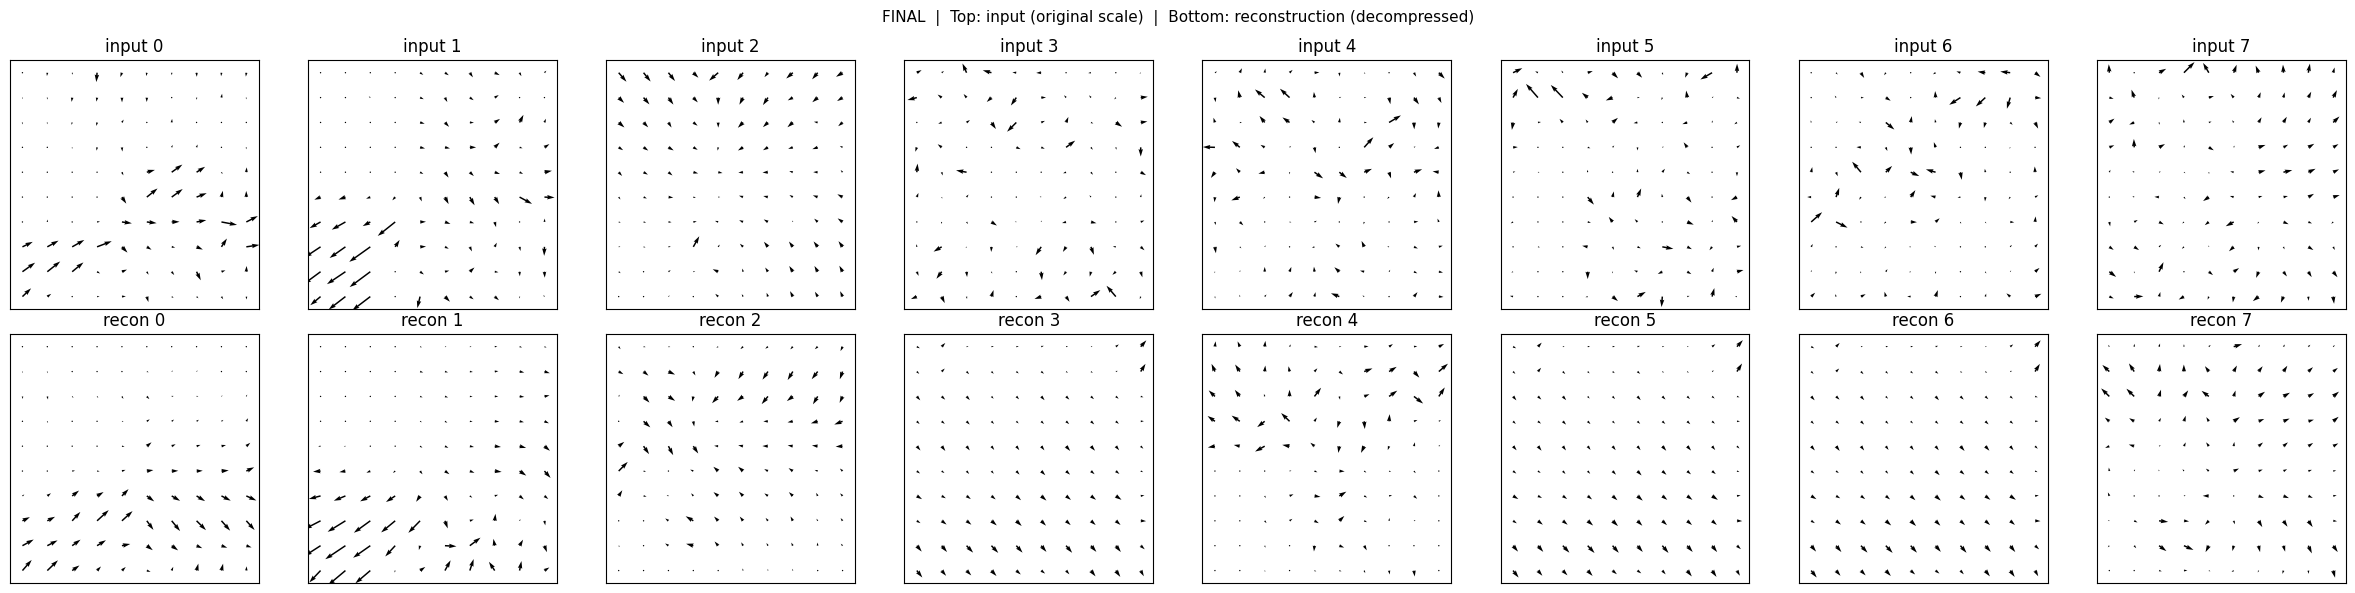

(8, 16)


In [92]:
_rng_vis = np.random.default_rng(0)
_vis_idx = _rng_vis.integers(0, N_total, size=8*3)[-8:]
_x_vis   = torch.from_numpy(X_grid_norm[_vis_idx]).to(DEVICE)

ss_vae.eval()
with torch.no_grad():
    _x_hat_vis, _, _, _ = ss_vae(_x_vis, sample=False)

_x_comp  = _x_vis.cpu().numpy()
_xh_comp = _x_hat_vis.cpu().numpy()

_x_orig  = _x_comp
_xh_orig = _xh_comp

fig, axes = plt.subplots(2, 8, figsize=(24, 6))
fig.suptitle("FINAL  |  Top: input (original scale)  |  "
             "Bottom: reconstruction (decompressed)", fontsize=11)
for i in range(8):
    plot_motion_grid(mag_compress(_x_orig[i], 0.5),  title=f"input {i}",  ax=axes[0, i])
    plot_motion_grid(mag_compress(_xh_orig[i], 0.5), title=f"recon {i}", ax=axes[1, i])
plt.tight_layout()
plt.show()

print((encode(_x_comp.reshape(8, -1)) - encode(_xh_comp.reshape(8, -1))).shape)

In [ ]:
# torch.save({
#     'model_state': ss_vae.state_dict(),
#     'hparams': {
#         'N_SUPERVISED': N_SUPERVISED,
#         'N_FREE': N_FREE,
#         'LATENT_CH': LATENT_CH,
#         'BETA_SUP': BETA_SUP,
#         'BETA_FREE': BETA_FREE,
#         'COV_WEIGHT': COV_WEIGHT,
#         'PCA_WEIGHT': PCA_WEIGHT,
#         'PCA_COMPONENTS': PCA_COMPONENTS,
#         'PCA_SKIP': PCA_SKIP,
#         'AUX_WEIGHT': AUX_WEIGHT,
#         'MAG_SCALE': MAG_SCALE,
#         'FREE_BITS': FREE_BITS,
#     },
#     'pca_mean': pca_mean_t,
#     'pca_comp': pca_comp_t,
#     'scale': _scale,
# }, CHECKPOINTS_DIR / "ss_vae_3sup_14free.pt")

(<Figure size 400x400 with 1 Axes>, <Axes: title={'center': 'Motion grid'}>)

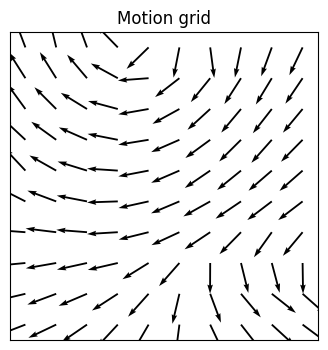

In [ ]:
def unit_norm_grid(grid):
    """grid: [2, 10, 10] — normalise each arrow to unit length."""
    mag = np.linalg.norm(grid, axis=0, keepdims=True)  # [1, 10, 10]
    return grid / (mag + 1e-8)

mag = np.linalg.norm(_x_np[7], axis=0)

scale = 1.0
plot_motion_grid((mag*(1-scale)+scale)*unit_norm_grid(_x_np[7]))

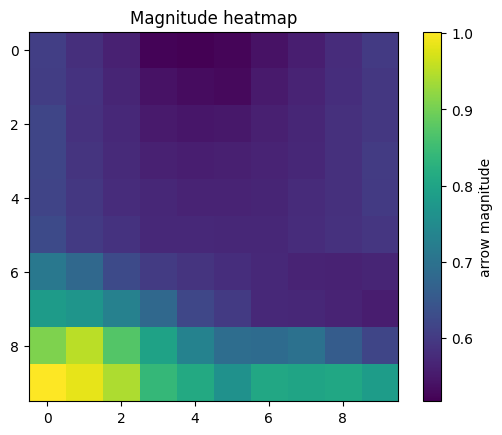

In [ ]:
mag = np.linalg.norm(_x_np[7], axis=0)

plt.imshow(mag*0.5+0.5, cmap='viridis')
plt.colorbar(label='arrow magnitude')
plt.title('Magnitude heatmap')
plt.show()